# Heart Disease Risk Prediction

This notebook implements logistic regression from scratch to predict heart disease, including exploratory analysis, visualization, regularization, and preparation for training in Amazon SageMaker.

## Step 1: Load and prepare the dataset

We load the `heart.csv` file, binarize the target variable, and explore the dataset's initial information.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("heart.csv")

# Ensure the target variable is binary
df["target"] = (df["target"] > 0).astype(int)

# Select the six required clinical features
selected_features = [
    "age",
    "chol",
    "trestbps",
    "thalach",
    "oldpeak",
    "ca"
]

# Display basic information
print("Shape:", df.shape)
print(df[selected_features + ["target"]].head())

# Display target distribution
print("\nTarget counts:")
print(df["target"].value_counts())

# Display missing values
print("\nMissing values:")
print(df.isna().sum())

Shape: (1025, 14)
   age  chol  trestbps  thalach  oldpeak  ca  target
0   52   212       125      168      1.0   2       0
1   53   203       140      155      3.1   0       0
2   70   174       145      125      2.6   0       0
3   61   203       148      161      0.0   1       0
4   62   294       138      106      1.9   3       0

Target counts:
1    526
0    499
Name: target, dtype: int64

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Exploratory analysis

We review the descriptive statistics of the numerical variables and the target class distribution.

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2
ca,1025.0,0.754146,1.030798,0.0,0.0,0.0,1.0,4.0
target,1025.0,0.513171,0.500070,0.0,0.0,1.0,1.0,1.0


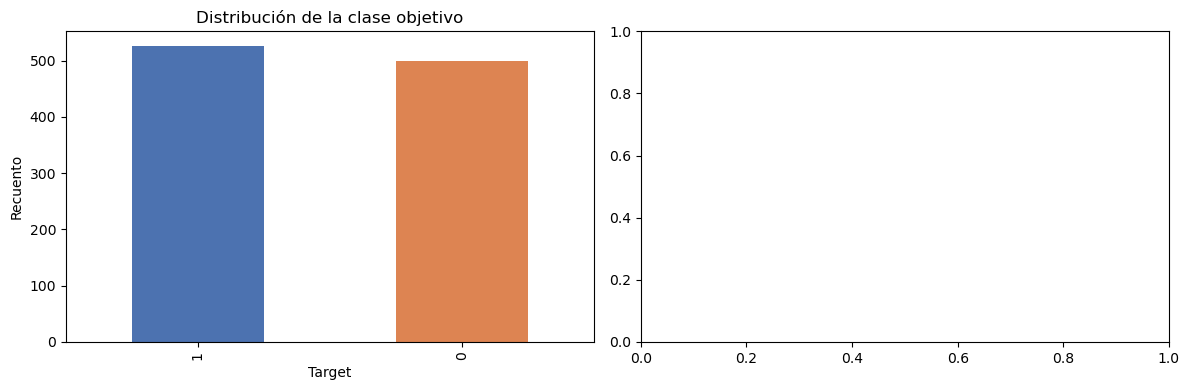

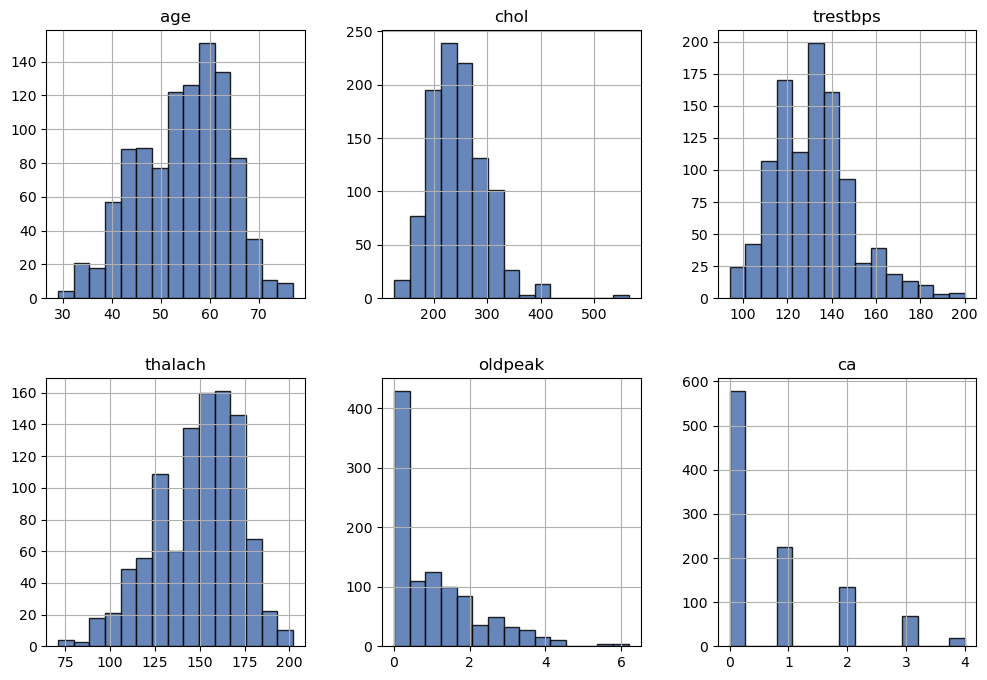

In [ ]:
display(df[selected_features + ['target']].describe().T)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['target'].value_counts().plot(kind='bar', ax=ax[0], color=['#4c72b0', '#dd8452'])
ax[0].set_title('Target class distribution')
ax[0].set_xlabel('Target')
ax[0].set_ylabel('Count')

df[selected_features].hist(bins=15, figsize=(12, 8), color='#4c72b0', edgecolor='black', layout=(2, 3), alpha=0.85)
fig.tight_layout()

Key observations:
- There are no missing values in the selected columns.
- The dataset is balanced between class 0 and class 1.
- The selected features are clinically relevant for heart disease.

### Data splitting and normalization

We perform a stratified 70/30 split and normalize numerical features using the training mean and standard deviation.

In [6]:
def stratified_train_test_split(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.arange(len(y))
    train_idx = []
    test_idx = []
    for label in np.unique(y):
        label_indices = indices[y == label]  # type: ignore
        np.random.shuffle(label_indices)
        n_test = int(len(label_indices) * test_size)
        test_idx.extend(label_indices[:n_test])
        train_idx.extend(label_indices[n_test:])
    return np.array(train_idx), np.array(test_idx)

X = df[selected_features].astype(float).to_numpy()
y = df['target'].to_numpy()
train_idx, test_idx = stratified_train_test_split(X, y, test_size=0.3, random_state=123)

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0, ddof=0)
X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train target distribution:', np.bincount(y_train))
print('Test target distribution:', np.bincount(y_test))

Train shape: (719, 6)
Test shape: (306, 6)
Train target distribution: [350 369]
Test target distribution: [149 157]


## Step 2: Implement basic logistic regression

We implement the model functions: `sigmoid`, cost, gradient, parameter updates, and prediction.

In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def compute_cost(X, y, w, b, lam=0.0):
    m = len(y)
    z = X.dot(w) + b
    p = sigmoid(z)
    eps = 1e-9
    cost = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    if lam > 0:
        cost += lam * np.sum(w ** 2) / (2 * m)
    return cost

def compute_gradient(X, y, w, b, lam=0.0):
    m = len(y)
    z = X.dot(w) + b
    p = sigmoid(z)
    dz = p - y
    dw = X.T.dot(dz) / m
    db = np.mean(dz)
    if lam > 0:
        dw += (lam / m) * w
    return dw, db

def train_logistic_regression(X, y, lr=0.01, epochs=1000, lam=0.0):
    w = np.zeros(X.shape[1])
    b = 0.0
    history = []
    for i in range(epochs):
        dw, db = compute_gradient(X, y, w, b, lam)
        w -= lr * dw
        b -= lr * db
        history.append(compute_cost(X, y, w, b, lam))
    return w, b, np.array(history)

def predict_proba(X, w, b):
    return sigmoid(X.dot(w) + b)

def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    eps = 1e-9
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

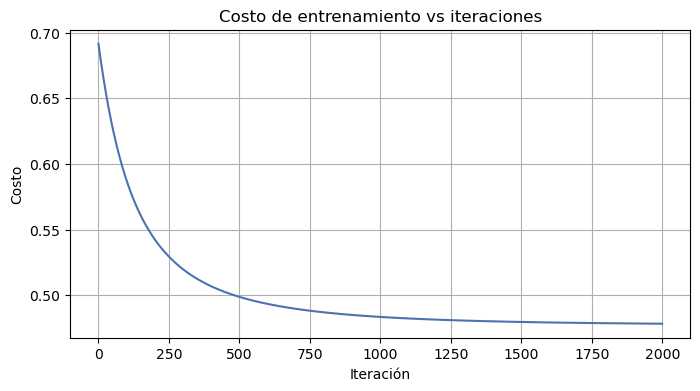

In [ ]:
lr = 0.01
epochs = 2000
w, b, cost_history = train_logistic_regression(X_train, y_train, lr=lr, epochs=epochs, lam=0.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_history, color='#4c72b0')
ax.set_title('Training cost vs iterations')
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost')
ax.grid(True)
plt.show()

In [9]:
train_preds = predict(X_train, w, b)
test_preds = predict(X_test, w, b)
train_metrics = compute_metrics(y_train, train_preds)
test_metrics = compute_metrics(y_test, test_preds)
metrics_df = pd.DataFrame([train_metrics, test_metrics], index=['train', 'test']).round(4)
display(metrics_df)

coefficients = pd.DataFrame({
    'feature': selected_features,
    'weight': w
})
display(coefficients)

,accuracy,precision,recall,f1
train,0.7650,0.7513,0.8103,0.7797
test,0.7516,0.7396,0.7962,0.7669


,feature,weight
0,age,-0.036916
1,chol,-0.051554
2,trestbps,-0.083104
3,thalach,0.699922
4,oldpeak,-0.802604
5,ca,-0.779154


The model converges with the expected decreasing cost, and the coefficients show how each feature influences disease prediction.

## Step 3: Visualize decision boundaries

We train models on feature pairs and plot decision regions in 2D.

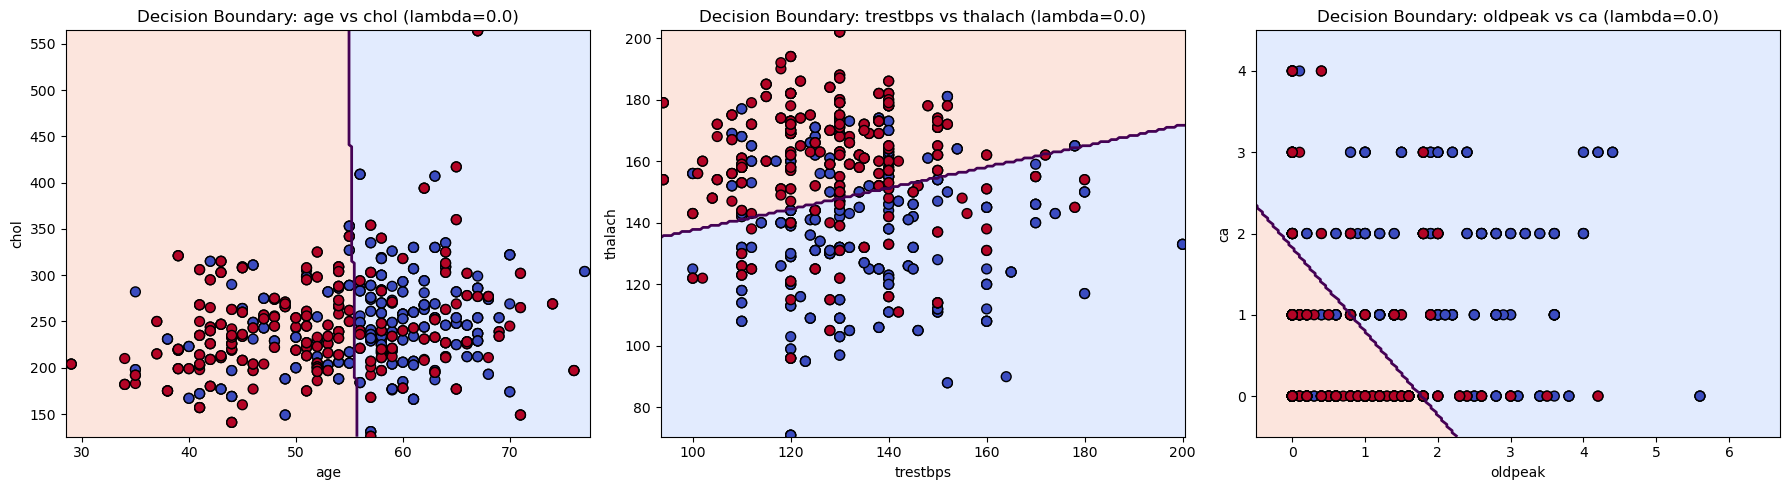

In [11]:

def plot_pair_decision_boundary(
    df,
    feature_pair,
    target,
    ax=None,
    lr=0.01,
    epochs=1000,
    lam=0.0
):
    # Select the two features and target
    X_pair = df[list(feature_pair)].astype(float).to_numpy()
    y_pair = df[target].to_numpy()

    # Create a stratified train/test split
    train_idx, test_idx = stratified_train_test_split(
        X_pair,
        y_pair,
        test_size=0.3,
        random_state=123
    )

    X_tr = X_pair[train_idx]
    y_tr = y_pair[train_idx]

    # Standardize training data
    mean = X_tr.mean(axis=0)
    std = X_tr.std(axis=0, ddof=0)

    X_tr_scaled = (X_tr - mean) / std

    # Train logistic regression
    w_pair, b_pair, _ = train_logistic_regression(
        X_tr_scaled,
        y_tr,
        lr=lr,
        epochs=epochs,
        lam=lam
    )

    # Create the plot if an axis was not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # Create a grid using the original feature values
    x_min = X_pair[:, 0].min() - 0.5
    x_max = X_pair[:, 0].max() + 0.5

    y_min = X_pair[:, 1].min() - 0.5
    y_max = X_pair[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Combine grid coordinates
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Standardize the grid using training statistics
    grid_scaled = (grid - mean) / std

    # Calculate predicted probabilities
    zz = predict(
        grid_scaled,
        w_pair,
        b_pair
    ).reshape(xx.shape)

    # Plot probability regions
    ax.contourf(
        xx,
        yy,
        zz,
        levels=[0, 0.5, 1],
        alpha=0.25,
        cmap="coolwarm"
    )

    # Plot the decision boundary at probability = 0.5
    ax.contour(
        xx,
        yy,
        zz,
        levels=[0.5],
        linewidths=2
    )

    # Plot training observations
    scatter = ax.scatter(
        X_tr[:, 0],
        X_tr[:, 1],
        c=y_tr,
        cmap="coolwarm",
        edgecolor="black",
        s=50
    )

    # Labels and title
    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])

    ax.set_title(
        f"Decision Boundary: {feature_pair[0]} vs {feature_pair[1]} "
        f"(lambda={lam})"
    )

    return w_pair, b_pair


# Feature pairs required by the assignment
feature_pairs = [
    ("age", "chol"),
    ("trestbps", "thalach"),
    ("oldpeak", "ca")
]

# Create the three decision boundary plots
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for idx, pair in enumerate(feature_pairs):
    plot_pair_decision_boundary(
        df,
        pair,
        "target",
        ax=axes[idx],
        lr=0.01,
        epochs=1500,
        lam=0.0
    )

fig.tight_layout()
plt.show()

Each plot indicates whether linear class separation is clear. If regions overlap, a nonlinear relationship or additional variables may be needed to improve separation.

## Step 4: Repeat with L2 regularization

We add an L2 penalty to the cost and gradient and compare several lambda values.

In [12]:
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0]
results = []
for lam in lambdas:
    w_reg, b_reg, _ = train_logistic_regression(X_train, y_train, lr=0.01, epochs=2000, lam=lam)
    train_pred = predict(X_train, w_reg, b_reg)
    test_pred = predict(X_test, w_reg, b_reg)
    train_m = compute_metrics(y_train, train_pred)
    test_m = compute_metrics(y_test, test_pred)
    results.append({
        'lambda': lam,
        'train_accuracy': train_m['accuracy'],
        'test_accuracy': test_m['accuracy'],
        'train_precision': train_m['precision'],
        'test_precision': test_m['precision'],
        'train_recall': train_m['recall'],
        'test_recall': test_m['recall'],
        'train_f1': train_m['f1'],
        'test_f1': test_m['f1'],
        'weight_norm': np.linalg.norm(w_reg),
    })
results_df = pd.DataFrame(results).round(4)
display(results_df)

,lambda,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,weight_norm
0,0.000,0.765,0.7516,0.7513,0.7396,0.8103,0.7962,0.7797,0.7669,1.3237
1,0.001,0.765,0.7516,0.7513,0.7396,0.8103,0.7962,0.7797,0.7669,1.3236
2,0.010,0.765,0.7516,0.7513,0.7396,0.8103,0.7962,0.7797,0.7669,1.3235
3,0.100,0.765,0.7516,0.7513,0.7396,0.8103,0.7962,0.7797,0.7669,1.3225
4,1.000,0.765,0.7516,0.7513,0.7396,0.8103,0.7962,0.7797,0.7669,1.3127


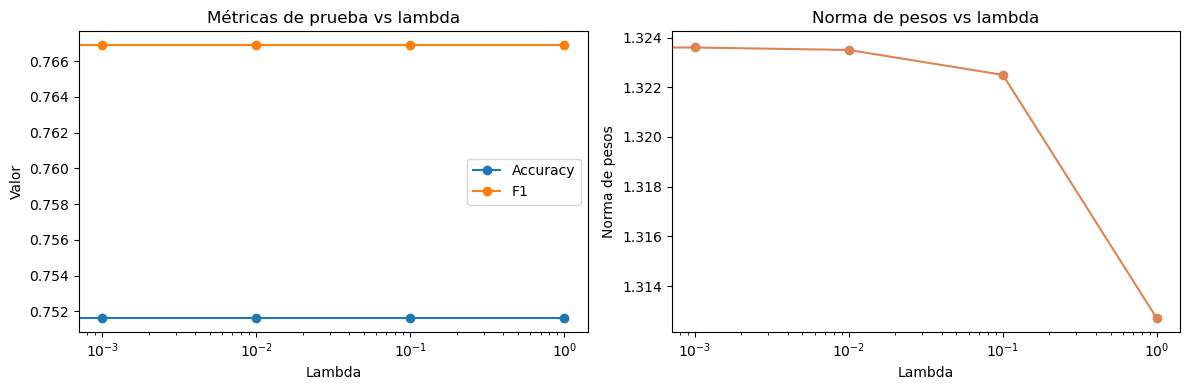

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(results_df['lambda'], results_df['test_accuracy'], marker='o', label='Accuracy')
ax[0].plot(results_df['lambda'], results_df['test_f1'], marker='o', label='F1')
ax[0].set_xscale('log')
ax[0].set_xlabel('Lambda')
ax[0].set_ylabel('Value')
ax[0].set_title('Test metrics vs lambda')
ax[0].legend()

ax[1].plot(results_df['lambda'], results_df['weight_norm'], marker='o', color='#dd8452')
ax[1].set_xscale('log')
ax[1].set_xlabel('Lambda')
ax[1].set_ylabel('Weight norm')
ax[1].set_title('Weight norm vs lambda')
plt.tight_layout()

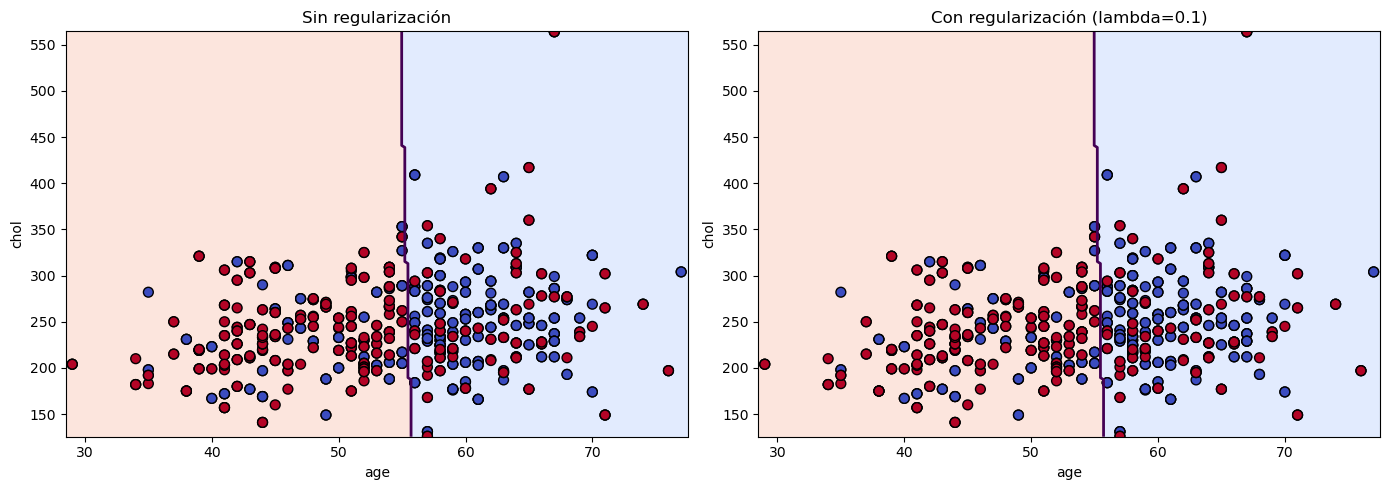

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_pair_decision_boundary(df, ('age', 'chol'), 'target', ax=axes[0], lr=0.01, epochs=1500, lam=0.0)
plot_pair_decision_boundary(df, ('age', 'chol'), 'target', ax=axes[1], lr=0.01, epochs=1500, lam=0.1)
axes[0].set_title('Without regularization')
axes[1].set_title('With regularization (lambda=0.1)')
plt.tight_layout()

As lambda increases, the weights shrink and the model becomes less complex, which may help reduce overfitting.

## Step 5: Prepare training and testing in SageMaker

In this section, we generate the data files that can be uploaded to Amazon SageMaker and describe how to run training in that environment.

In [15]:
train_df = pd.DataFrame(np.column_stack([X_train, y_train]), columns=selected_features + ['target'])
test_df = pd.DataFrame(np.column_stack([X_test, y_test]), columns=selected_features + ['target'])
train_df.to_csv('heart_train.csv', index=False)
test_df.to_csv('heart_test.csv', index=False)
print('heart_train.csv and heart_test.csv saved for SageMaker upload.')

heart_train.csv and heart_test.csv saved for SageMaker upload.


### SageMaker instructions

1. Open a notebook in AWS Academy SageMaker.
2. Upload `heart_train.csv`, `heart_test.csv`, and `sagemaker_train.py` to the environment.
3. Run `python sagemaker_train.py` to train the model.
4. Load `heart_test.csv` and evaluate with the metrics code in the same notebook.

The previous section demonstrates how to prepare the data and training script without using a deployed endpoint, as required by the assignment.

## Conclusions

- Logistic regression was implemented successfully using NumPy and Pandas.
- Exploratory analysis showed that the dataset is balanced and has no missing values in the selected variables.
- Decision boundaries for feature pairs show that some relationships are less linear and may require more than two dimensions for good separation.
- L2 regularization stabilizes the weights, reduces model complexity, and helps select a lambda value that generalizes better.
- The notebook includes data preparation for SageMaker and a training script for use in the managed environment.